In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing import image

In [ ]:
import os

# Ganti dengan username dan key dari akun Kaggle kamu sendiri
os.environ['KAGGLE_USERNAME'] = "gunafatala"
os.environ['KAGGLE_KEY'] = "KGAT_59792fb1e928dde5aba2600bf76497b3"

print("✅ Kredensial Kaggle berhasil dipasang!")

✅ Kredensial Kaggle berhasil dipasang!


In [ ]:
# 1. Mengunduh dataset dari Kaggle
!kaggle datasets download -d fathurrahmanalfarizy/sampah-daur-ulang

# 2. Mengekstrak file zip secara diam-diam (-q) ke dalam folder 'dataset_sampah'
!unzip -q sampah-daur-ulang.zip -d dataset_sampah

print("✅ Dataset berhasil diunduh dan diekstrak!")

Dataset URL: https://www.kaggle.com/datasets/fathurrahmanalfarizy/sampah-daur-ulang
License(s): unknown
100% 98.5M/98.5M [00:06<00:00, 16.9MB/s]

✅ Dataset berhasil diunduh dan diekstrak!


In [ ]:
base_path = "dataset_sampah/DATASETS"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
def prep_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

In [ ]:
def get_dataset_path(base_path):
    classes = sorted(os.listdir(base_path))
    file_paths = []
    labels = []

    for i, class_name in enumerate(classes):
        class_dir = os.path.join(base_path, class_name)
        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                file_paths.append(os.path.join(class_dir, file_name))
                labels.append(i)

    return file_paths, labels, classes

In [ ]:
file_paths, labels, class_names = get_dataset_path(base_path)

print(f"Found {len(file_paths)} images in {len(class_names)} classes.")

Found 7014 images in 6 classes.


In [ ]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    test_paths, test_labels, test_size=0.5, random_state=42, stratify=test_labels
)

In [ ]:
def create_dataset(file_paths, labels):
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    dataset = dataset.map(prep_image, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size = 1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
train_dataset = create_dataset(train_paths, train_labels)
test_dataset = create_dataset(test_paths, test_labels)
val_dataset = create_dataset(val_paths, val_labels)

In [ ]:
def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.3)
    img = tf.image.random_contrast(img, lower=0.6, upper=1.4)
    img = tf.image.random_saturation(img, lower=0.6, upper=1.4)
    img = tf.image.random_hue(img, max_delta=0.1)
    return img, label


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model

def build_model(num_classes):
    # 1. Definisikan Input secara eksplisit (Wajib di Functional API)
    inputs = Input(shape=IMG_SIZE + (3,))

    # 2. Inisialisasi Base Model
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=IMG_SIZE + (3,))
    base_model.trainable = True  # Fine-tune seluruh layer (sudah benar)

    # 3. Sambungkan layer seperti rantai fungsi
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    # 4. Output Layer
    outputs = Dense(num_classes, activation='softmax')(x)

    # 5. Bungkus menjadi tf.keras.Model
    model = Model(inputs=inputs, outputs=outputs)

    return model

# Nanti saat dipanggil, pastikan num_classes = 5 (sesuai batasan proyek)
# num_classes = len(class_names)
# model = build_model(num_classes)

In [ ]:
num_classes = len(class_names)
model = build_model(num_classes)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,590 (9.99 MB)

 Trainable params: 2,585,478 (9.86 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
import tensorflow as tf

# 1. Definisikan Komponen Kustom Lanjutan (Memenuhi Main Quest)
class TargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # Mengambil nilai metrik dari log training
        acc = logs.get('accuracy')
        mae = logs.get('mae')

        # Keamanan ganda memastikan metrik tidak kosong
        if acc is not None and mae is not None:
            if acc >= 0.85 and mae <= 0.02:
                print(f"\n✅ Target MBKM Tercapai! Akurasi: {acc*100:.2f}%, MAE: {mae:.4f}")
                print("Misi Selesai. Menghentikan proses training agar tidak overfitting...")
                self.model.stop_training = True

# 2. Inisialisasi callback kustom
custom_target_stop = TargetCallback()

# 3. Gabungkan callback temanmu dengan callback kustom ini
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# Ini yang nanti akan dipanggil di dalam model.fit()
callbacks_list = [early_stop, reduce_lr, custom_target_stop]

In [ ]:
import tensorflow as tf

# Membuat custom metrik MAE khusus untuk label sparse
def mae(y_true, y_pred):
    # Mengubah label angka tunggal menjadi matriks one-hot agar selaras dengan tebakan model
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[1])
    return tf.reduce_mean(tf.abs(y_true_one_hot - y_pred))

# Compile ulang modelnya
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy', mae]) # Memanggil fungsi mae buatan kita

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
import os

# 1. Hitung Class Weights (Kode temanmu yang brilian)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# 2. Persiapan SIDE QUEST: TensorBoard Callback
log_dir = "logs/fit/"
os.makedirs(log_dir, exist_ok=True)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# 3. Gabungkan SEMUA konduktor (bawaan + custom + tensorboard)
final_callbacks = [early_stop, reduce_lr, custom_target_stop, tensorboard_callback]

# 4. Eksekusi Training (Showtime!)
print("Memulai proses training model...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=final_callbacks  # <-- Perubahan krusial ada di sini
)

Memulai proses training model...
Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 141s 434ms/step - accuracy: 0.1968 - loss: 2.1605 - mae: 0.2715 - val_accuracy: 0.3310 - val_loss: 1.6226 - val_mae: 0.2627 - learning_rate: 1.0000e-05
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 149ms/step - accuracy: 0.2896 - loss: 1.7758 - mae: 0.2562 - val_accuracy: 0.5050 - val_loss: 1.3951 - val_mae: 0.2438 - learning_rate: 1.0000e-05
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - accuracy: 0.3671 - loss: 1.5712 - mae: 0.2431 - val_accuracy: 0.6262 - val_loss: 1.1890 - val_mae: 0.2206 - learning_rate: 1.0000e-05
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 143ms/step - accuracy: 0.4420 - loss: 1.4070 - mae: 0.2288 - val_accuracy: 0.6819 - val_loss: 1.0096 - val_mae: 0.1956 - learning_rate: 1.0000e-05
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 27s 146ms/step - accuracy: 0.5106 - loss: 1.2507 - mae: 0.2122 - val_accuracy: 0.7432 - val_loss: 0.8684 - val_mae: 0.1727 - learning_rate: 1.0000e-05
Epoch 6/10


In [ ]:
print("Melanjutkan proses training model (Target: Akurasi >= 85%, MAE <= 0.02)...")

# Kita tingkatkan epoch agar model punya cukup waktu mencapai target Side Quest
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50, # <-- Dinaikkan menjadi 50
    class_weight=class_weights_dict,
    callbacks=final_callbacks
)

Melanjutkan proses training model (Target: Akurasi >= 85%, MAE <= 0.02)...
Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 150ms/step - accuracy: 0.7539 - loss: 0.6731 - mae: 0.1244 - val_accuracy: 0.8431 - val_loss: 0.4434 - val_mae: 0.0856 - learning_rate: 1.0000e-05
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 27s 145ms/step - accuracy: 0.7854 - loss: 0.6207 - mae: 0.1129 - val_accuracy: 0.8616 - val_loss: 0.4039 - val_mae: 0.0767 - learning_rate: 1.0000e-05
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 27s 145ms/step - accuracy: 0.8020 - loss: 0.5649 - mae: 0.1041 - val_accuracy: 0.8631 - val_loss: 0.3810 - val_mae: 0.0714 - learning_rate: 1.0000e-05
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 143ms/step - accuracy: 0.8232 - loss: 0.5263 - mae: 0.0961 - val_accuracy: 0.8730 - val_loss: 0.3660 - val_mae: 0.0671 - learning_rate: 1.0000e-05
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 142ms/step - accuracy: 0.8303 - loss: 0.4771 - mae: 0.0899 - val_accuracy: 0.8802 - val_loss: 0.3503 - val_mae: 0.062

In [ ]:
# Tambahkan test_mae untuk menampung output ketiga
test_loss, test_accuracy, test_mae = model.evaluate(test_dataset)

print(f"📊 Hasil Ujian Akhir Model:")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test MAE      : {test_mae:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9031 - loss: 0.2831 - mae: 0.0413
📊 Hasil Ujian Akhir Model:
Test Accuracy : 90.31%
Test MAE      : 0.0413


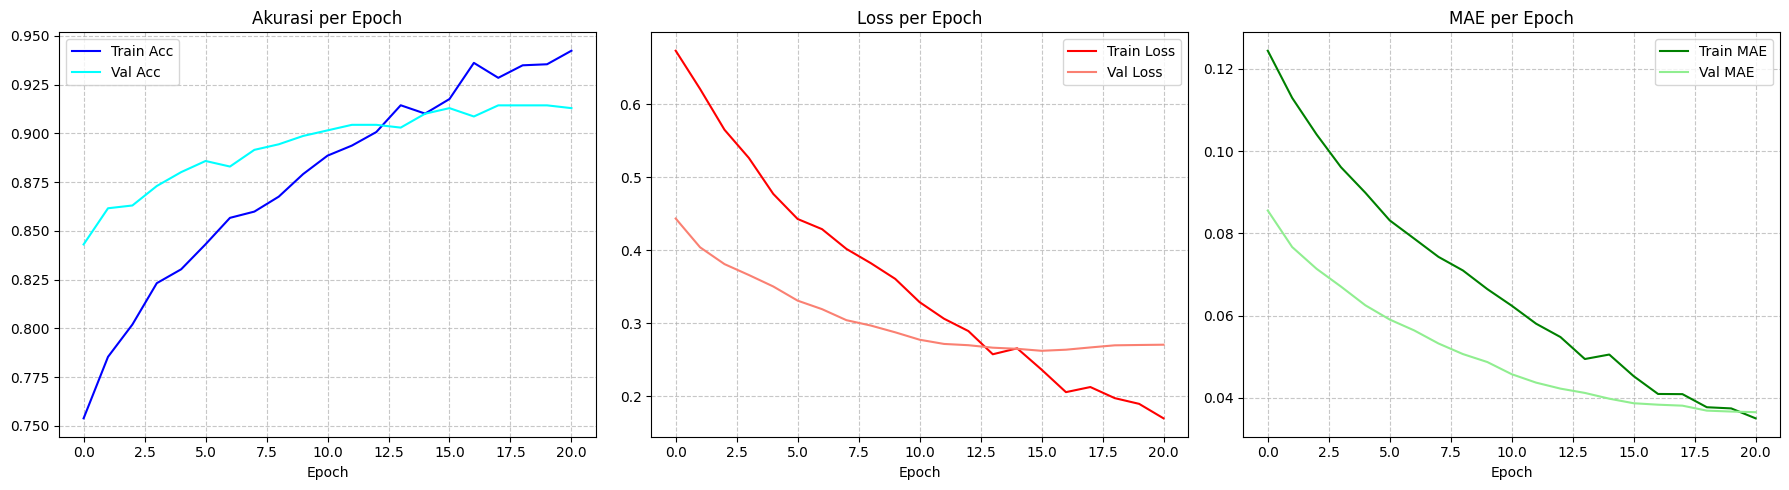

In [ ]:
import matplotlib.pyplot as plt

# Membuat kanvas yang lebar untuk 3 grafik
plt.figure(figsize=(18, 5))

# 1. Grafik Akurasi
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='cyan')
plt.legend()
plt.title('Akurasi per Epoch')
plt.xlabel('Epoch')
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Grafik Loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Val Loss', color='salmon')
plt.legend()
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Grafik MAE (Pembuktian Side Quest)
plt.subplot(1, 3, 3)
plt.plot(history.history['mae'], label='Train MAE', color='green')
plt.plot(history.history['val_mae'], label='Val MAE', color='lightgreen')
plt.legend()
plt.title('MAE per Epoch')
plt.xlabel('Epoch')
plt.grid(True, linestyle='--', alpha=0.7)

# Menampilkan semua grafik
plt.tight_layout()
plt.show()

In [ ]:
model.save("sampah_classifier.keras")

📚 Daftar kelas yang dikenali: ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']
✅ Model berhasil dimuat.

🔼 Silakan unggah gambar...


Saving kaca.jpg to kaca (1).jpg

📷 Memproses gambar: kaca (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

🔍 Detail Probabilitas:
 - Kaca: 99.86%
 - Kardus: 0.00%
 - Kertas: 0.01%
 - Logam: 0.01%
 - Plastik: 0.10%
 - Residu: 0.02%


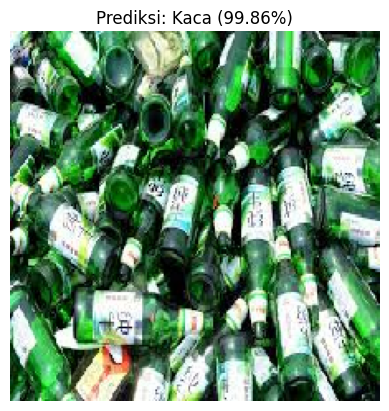

✅ Hasil: KACA (99.86%)
➕ Apakah ada gambar lain yang ingin dimasukkan? (ya/tidak): ya

🔼 Silakan unggah gambar...


Saving kardus.jpg to kardus.jpg

📷 Memproses gambar: kardus.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

🔍 Detail Probabilitas:
 - Kaca: 0.00%
 - Kardus: 99.94%
 - Kertas: 0.06%
 - Logam: 0.00%
 - Plastik: 0.00%
 - Residu: 0.00%


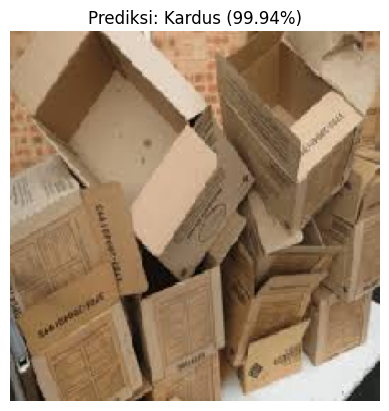

✅ Hasil: KARDUS (99.94%)
➕ Apakah ada gambar lain yang ingin dimasukkan? (ya/tidak): tidak

📊 REKAPITULASI PILAHYUK!
 - Kaca: 1 buah
 - Kardus: 1 buah

💰 Detail Perhitungan : 1 Kaca x Rp200 + 1 Kardus x Rp500
💵 Total Nilai Tukar  : Rp700


In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Parameter dan Setup ---
IMG_SIZE = (224, 224)
# Ganti dengan path DATASETS yang benar sesuai folder ekstraksi di Colab kamu
DATASET_PATH = "dataset_sampah/DATASETS"
UPLOAD_FOLDER = "sampah"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

# --- 2. Load class_names ---
class_names = sorted(os.listdir(DATASET_PATH))
print(f"📚 Daftar kelas yang dikenali: {class_names}")

# --- 3. Load model (DENGAN CUSTOM OBJECT) ---
# Wajib menyertakan custom_objects karena kita memakai metrik kustom 'mae' saat training
model = load_model("sampah_classifier.keras", custom_objects={'mae': mae})
print("✅ Model berhasil dimuat.")

# --- 4. Fungsi prediksi gambar ---
def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    predictions = model.predict(img_array)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index]

    print("\n🔍 Detail Probabilitas:")
    for i, prob in enumerate(predictions):
        print(f" - {class_names[i]}: {prob*100:.2f}%")

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediksi: {predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    return predicted_class, confidence

# --- 5. Fungsi perhitungan nilai tukar (Sudah diperbaiki hurufnya) ---
def calculate_exchange(sampah_count):
    # Menggunakan lowercase agar cocok 100% dengan class_names dari folder
    harga_sampah = {
        "plastik": 100,
        "kaca": 200,
        "kardus": 500,
        "kertas": 0,
        "logam": 100,
        "residu": 0
    }

    total_value = 0
    detail = []

    for jenis, jumlah in sampah_count.items():
        if jumlah > 0:
            value = harga_sampah.get(jenis.lower(), 0) * jumlah
            detail.append(f"{jumlah} {jenis.capitalize()} x Rp{harga_sampah.get(jenis.lower(), 0)}")
            total_value += value

    detail_str = " + ".join(detail)
    return total_value, detail_str

# --- 6. Proses Input dan Loop Prediksi ---
sampah_count = {jenis: 0 for jenis in class_names}

while True:
    print("\n🔼 Silakan unggah gambar...")
    uploaded = files.upload()

    if not uploaded: # Jika batal unggah
        print("Membatalkan unggahan...")
        break

    for filename in uploaded.keys():
        print(f"\n📷 Memproses gambar: {filename}")
        file_path = os.path.join(UPLOAD_FOLDER, filename)

        with open(file_path, 'wb') as f:
            f.write(uploaded[filename])

        predicted_class, confidence = predict_image(file_path)
        print(f"✅ Hasil: {predicted_class.upper()} ({confidence*100:.2f}%)")

        sampah_count[predicted_class] += 1

    another = input("➕ Apakah ada gambar lain yang ingin dimasukkan? (ya/tidak): ").strip().lower()
    if another != "ya":
        break

# --- 7. Tampilkan Hasil Akhir ---
print("\n==============================")
print("📊 REKAPITULASI PILAHYUK!")
print("==============================")
for jenis, jumlah in sampah_count.items():
    if jumlah > 0:
        print(f" - {jenis.capitalize()}: {jumlah} buah")

total_value, detail_str = calculate_exchange(sampah_count)
print(f"\n💰 Detail Perhitungan : {detail_str}")
print(f"💵 Total Nilai Tukar  : Rp{total_value}")
print("==============================")

In [ ]:
pip install fastapi uvicorn tensorflow pillow numpy python-multipart

In [ ]:
from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import io
from PIL import Image
import tensorflow as tf

# 1. Inisialisasi Aplikasi
app = FastAPI(title="API PilahYuk!")

# 2. Atur CORS (Sangat krusial untuk Next.js)
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"], # Mengizinkan request dari web manapun (bisa diubah spesifik ke localhost:3000 nanti)
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# 3. Definisikan ulang custom metric MAE (Wajib ada agar .keras bisa di-load)
def mae(y_true, y_pred):
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[1])
    return tf.reduce_mean(tf.abs(y_true_one_hot - y_pred))

# 4. Load Model saat server nyala
print("Memuat model AI PilahYuk!...")
model = load_model("sampah_classifier.keras", custom_objects={'mae': mae})

# Gunakan daftar kelas sementara (besok diubah jadi 5 kelas jika dataset sudah rapi)
class_names = ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']

@app.get("/")
def read_root():
    return {"pesan": "API PilahYuk! Berjalan Lancar 🚀"}

@app.post("/predict")
async def predict_sampah(file: UploadFile = File(...)):
    try:
        # Baca file gambar yang diupload Next.js
        contents = await file.read()

        # Konversi ke RGB untuk menghindari error gambar PNG ber-alpha channel (transparan)
        img = Image.open(io.BytesIO(contents)).convert("RGB")
        img = img.resize((224, 224))

        # Preprocessing (harus sama persis dengan fungsi prep_image di Colab)
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Eksekusi Prediksi
        predictions = model.predict(img_array)[0]
        predicted_index = np.argmax(predictions)

        # Ambil label dan probabilitas
        label = class_names[predicted_index]
        confidence = float(predictions[predicted_index])

        # Kembalikan response JSON yang rapi untuk dibaca Next.js
        return {
            "status": "success",
            "data": {
                "jenis_sampah": label,
                "confidence": confidence
            }
        }
    except Exception as e:
        return {"status": "error", "message": str(e)}

Memuat model AI PilahYuk!...
